# VoiceVision AI

## Notebook 03 : Model Training

### Objective

Train an EfficientNetB3 model using Transfer Learning.

Tasks

- Load datasets
- Build EfficientNetB3
- Create classification head
- Train model
- Save best model

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
DATASET_PATH = "/content/drive/MyDrive/VoiceVision-AI/01_Datasets/Waste_Images/Dataset"

In [27]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [28]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.0001

In [29]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [30]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

Found 9811 images belonging to 10 classes.


In [31]:
validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 2448 images belonging to 10 classes.


In [32]:
print("Classes:")
print(train_generator.class_indices)
print("\nNumber of Classes:", train_generator.num_classes)
print("\nTraining Images:", train_generator.samples)
print("Validation Images:", validation_generator.samples)

Classes:
{'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}

Number of Classes: 10

Training Images: 9811
Validation Images: 2448


In [33]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print("MobileNetV2 Loaded Successfully")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 Loaded Successfully


In [34]:
base_model.trainable = False
print("Base Model Frozen")

Base Model Frozen


In [35]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(
    512,
    activation='relu'
)(x)
x = Dropout(0.5)(x)
x = Dense(
    256,
    activation='relu'
)(x)
x = Dropout(0.3)(x)
predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)
model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [36]:
model.compile(
    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,047,754 (11.63 MB)

 Trainable params: 789,770 (3.01 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
SAVE_DIR = "/content/drive/MyDrive/VoiceVision-AI/03_Trained_Models"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)
print("Save Folder Ready")

Save Folder Ready


In [39]:
checkpoint = ModelCheckpoint(
    filepath=os.path.join(
        SAVE_DIR,
        "best_mobilenetv2.keras"
    ),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1

)

In [40]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]

)

Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.3982 - loss: 1.7860
Epoch 1: val_accuracy improved from None to 0.80270, saving model to /content/drive/MyDrive/VoiceVision-AI/03_Trained_Models/best_mobilenetv2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/VoiceVision-AI/03_Trained_Models/best_mobilenetv2.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 255s 768ms/step - accuracy: 0.5559 - loss: 1.3527 - val_accuracy: 0.8027 - val_loss: 0.6191 - learning_rate: 1.0000e-04
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.7446 - loss: 0.7858
Epoch 2: val_accuracy improved from 0.80270 to 0.83946, saving model to /content/drive/MyDrive/VoiceVision-AI/03_Trained_Models/best_mobilenetv2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/VoiceVision-AI/03_Trained_Models/best_mobilenetv2.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 205s 670ms/step - accuracy: 0.7536 - loss: 0.7486 - val_accuracy: 0.8395 - val_loss: 0.4955 - learning_rate: 1.0000e-04

In [41]:
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Fine Tuning Enabled")

Fine Tuning Enabled


In [42]:
model.compile(

    optimizer=Adam(
        learning_rate=1e-5
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [43]:
fine_history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10,

    callbacks=[

        checkpoint,

        early_stop,

        reduce_lr

    ]

)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.7907 - loss: 0.6444
Epoch 1: val_accuracy did not improve from 0.89502
307/307 ━━━━━━━━━━━━━━━━━━━━ 242s 726ms/step - accuracy: 0.8211 - loss: 0.5372 - val_accuracy: 0.8824 - val_loss: 0.3337 - learning_rate: 1.0000e-05
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.8482 - loss: 0.4362
Epoch 2: val_accuracy improved from 0.89502 to 0.89788, saving model to /content/drive/MyDrive/VoiceVision-AI/03_Trained_Models/best_mobilenetv2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/VoiceVision-AI/03_Trained_Models/best_mobilenetv2.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 209s 681ms/step - accuracy: 0.8540 - loss: 0.4233 - val_accuracy: 0.8979 - val_loss: 0.3032 - learning_rate: 1.0000e-05
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.8685 - loss: 0.3815
Epoch 3: val_accuracy did not improve from 0.89788
307/307 ━━━━━━━━━━━━━━━━━━━━ 208s 676ms/step - accuracy: 0.8729 - loss:

In [44]:
# Save final model
model.save(
    os.path.join(
        SAVE_DIR,
        "mobilenetv2_final.keras"
    )
)
print("Final Model Saved")

# Save class names
class_names = list(train_generator.class_indices.keys())

with open(
    os.path.join(
        SAVE_DIR,
        "class_names.json"
    ),
    "w"
) as f:
    json.dump(class_names, f)

print("Class Names Saved")

Final Model Saved
Class Names Saved


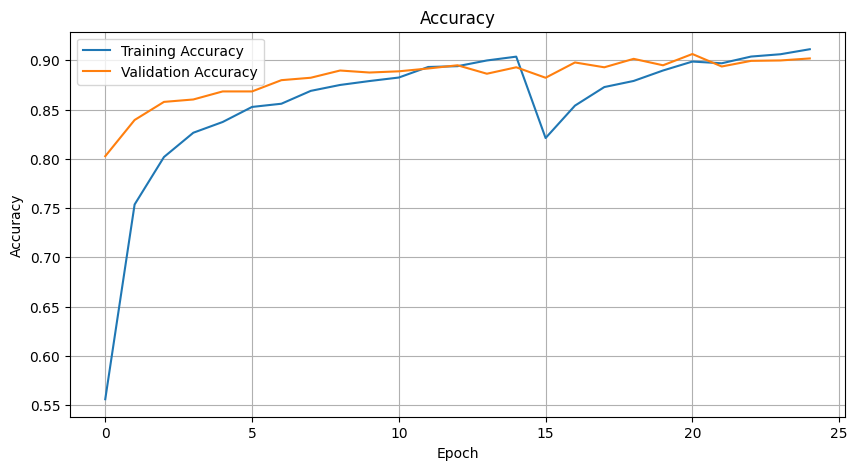

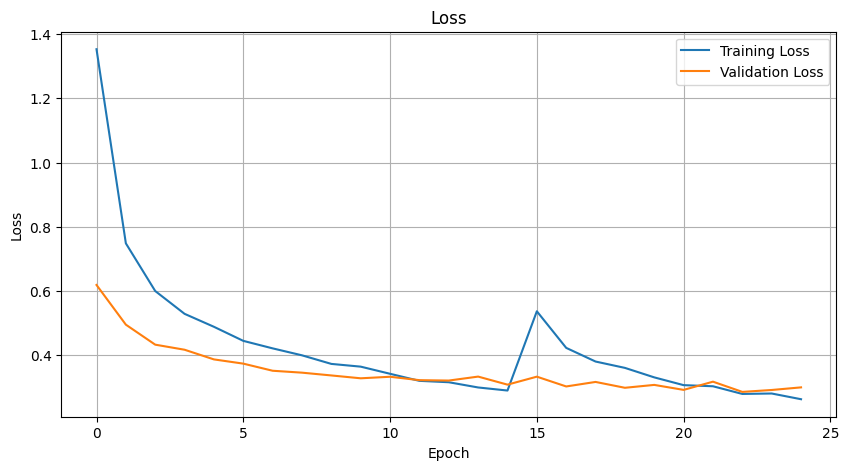

In [45]:
# Combine histories
train_acc = history.history["accuracy"] + fine_history.history["accuracy"]
val_acc = history.history["val_accuracy"] + fine_history.history["val_accuracy"]

train_loss = history.history["loss"] + fine_history.history["loss"]
val_loss = history.history["val_loss"] + fine_history.history["val_loss"]

# Accuracy Plot
plt.figure(figsize=(10,5))

plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# Loss Plot
plt.figure(figsize=(10,5))

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Predicted Class : battery
Confidence : 99.99275


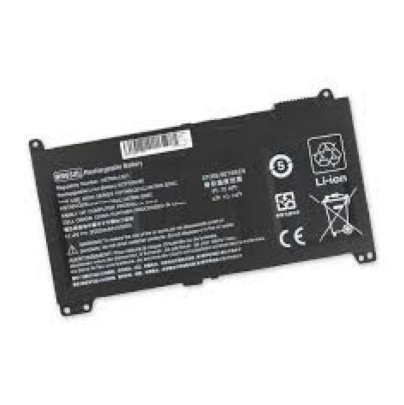

In [46]:
from tensorflow.keras.preprocessing import image

img_path = validation_generator.filepaths[0]

img = image.load_img(
    img_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

class_labels = list(train_generator.class_indices.keys())

print("Predicted Class :", class_labels[predicted_class])
print("Confidence :", np.max(prediction) * 100)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

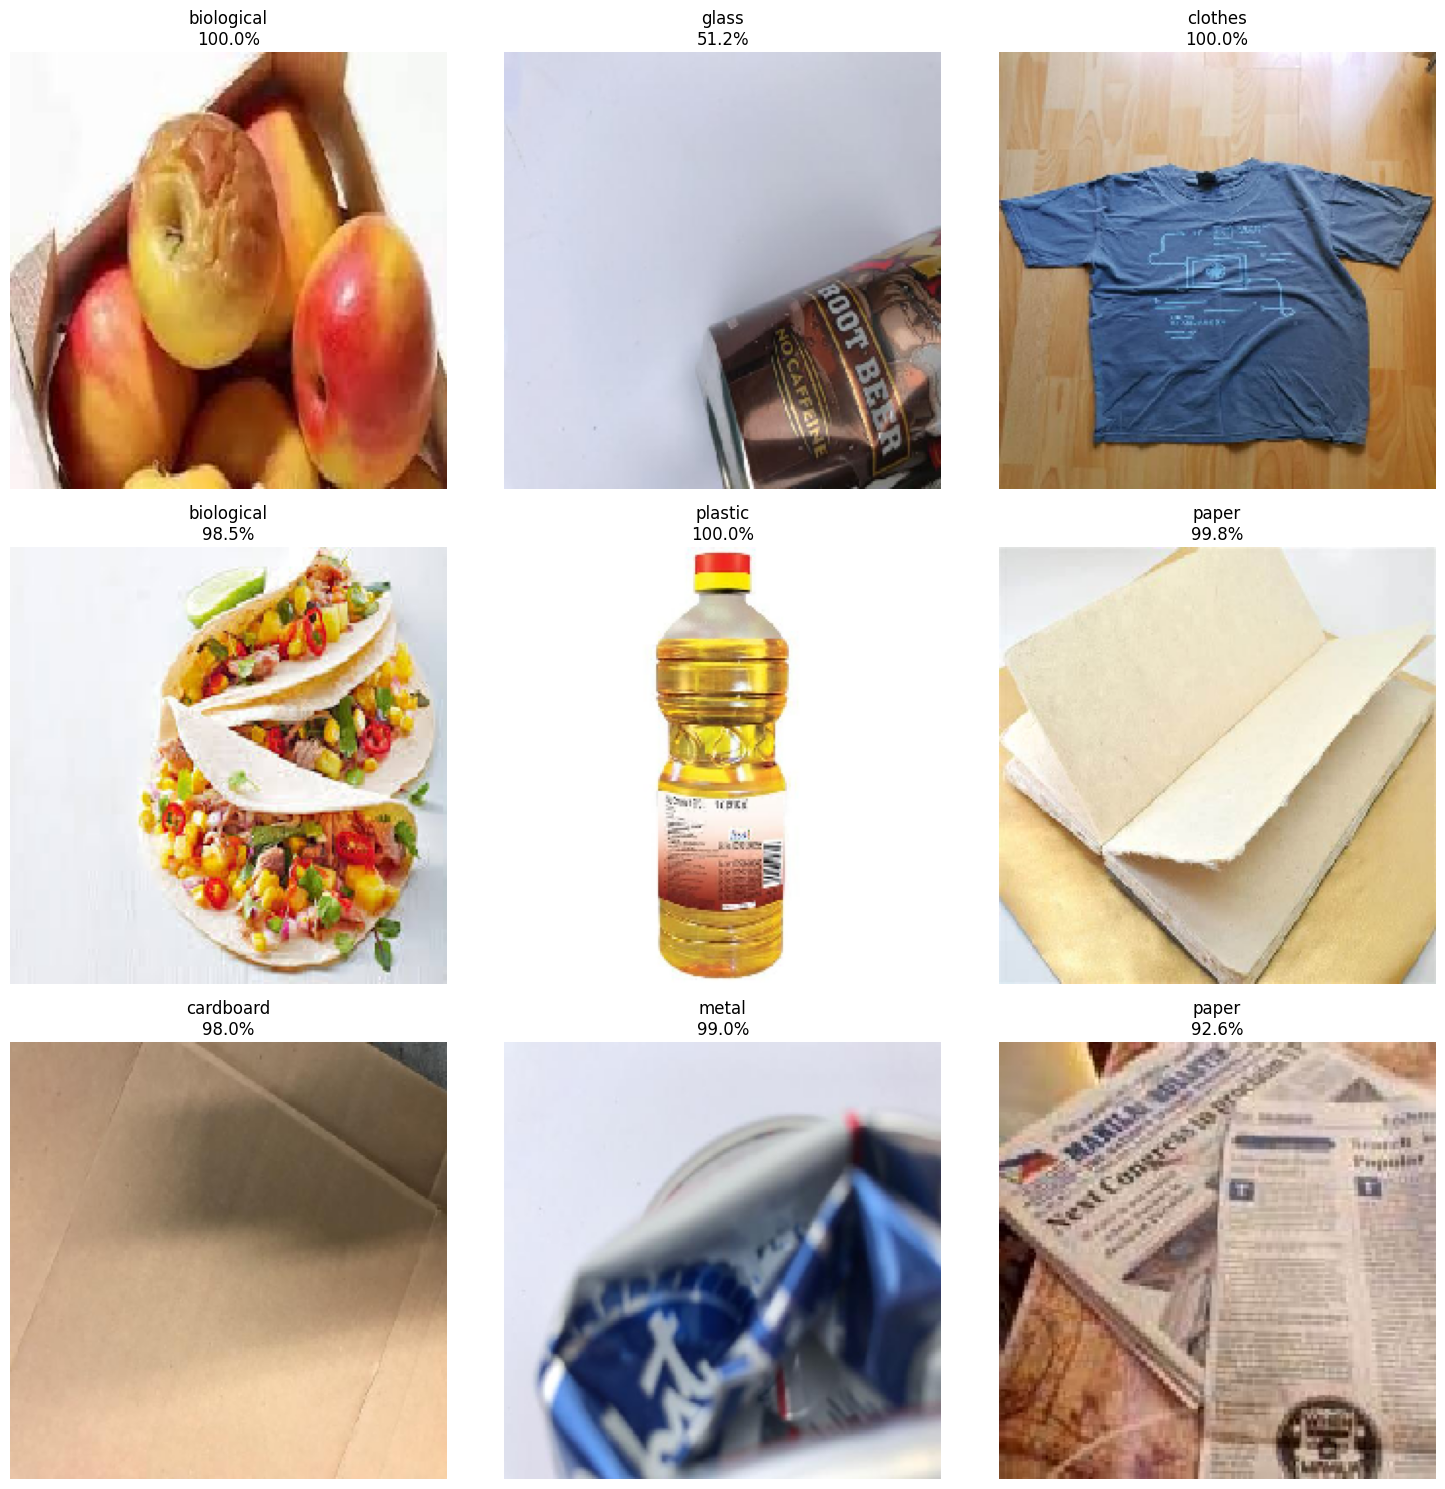

In [47]:
import random

plt.figure(figsize=(15,15))

for i in range(9):

    img_path = random.choice(validation_generator.filepaths)

    img = image.load_img(
        img_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array/255.0

    prediction = model.predict(img_array, verbose=0)

    predicted = np.argmax(prediction)

    confidence = np.max(prediction)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(
        f"{class_labels[predicted]}\n{confidence*100:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()